# Spin Observables and Correlations

**Model.** This notebook measures ground-state observables in a six-site transverse-field Ising chain. A tiny longitudinal field selects one finite-chain symmetry-broken branch so the magnetization is visible.

**Typical uses.** Ground-state diagnostics, field-driven crossover studies, correlation-length intuition, and validating observable calculations against exact diagonalization.

**Parameters.** `n_sites` sets the number of spins $N$; `h_x` is the transverse-field strength; `h_z` is the branch-selecting longitudinal-field strength; and `j` is the Ising coupling $J$. The examples use $h_z=10^{-3}$ and open boundaries.

**Useful plots.** Magnetization and nearest-neighbor correlations versus field, finite-size spectral gap, and distance-dependent $ZZ$ correlation profiles.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.models import longitudinal_field_ising
from quantum_lattice_models.observables import correlation_zz, magnetization_z
from quantum_lattice_models.spectra import ground_state, spectral_gap

In [2]:
n_sites = 6
fields = np.linspace(0.0, 2.0, 25)
magnetizations = []
nearest_correlations = []
gaps = []

for field in fields:
    H = longitudinal_field_ising(n_sites=n_sites, j=1.0, h_x=float(field), h_z=1e-3, periodic=False)
    _, state = ground_state(H)
    magnetizations.append(magnetization_z(state, n_sites))
    nearest_correlations.append(
        np.mean([correlation_zz(state, n_sites, i, i + 1) for i in range(n_sites - 1)])
    )
    gaps.append(spectral_gap(H))

print("TFIM observable sweep with h_z=1e-3 symmetry-breaking field")
print(f"  sites: {n_sites}")
print(f"  field range: {fields[0]:.1f} to {fields[-1]:.1f}")
print(f"  minimum finite-size gap: {min(gaps):.6f}")

TFIM observable sweep with h_z=1e-3 symmetry-breaking field
  sites: 6
  field range: 0.0 to 2.0
  minimum finite-size gap: 0.011813


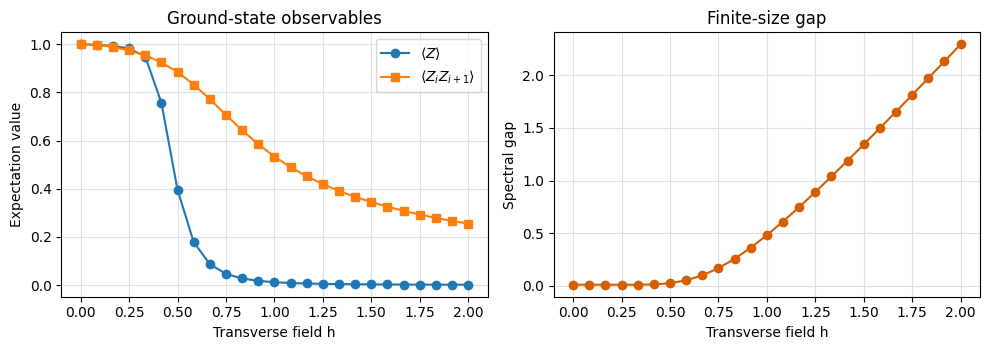

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(fields, magnetizations, marker="o", label=r"$\langle Z\rangle$")
axes[0].plot(fields, nearest_correlations, marker="s", label=r"$\langle Z_iZ_{i+1}\rangle$")
axes[0].set_xlabel("Transverse field h")
axes[0].set_ylabel("Expectation value")
axes[0].set_title("Ground-state observables")
axes[0].legend()

axes[1].plot(fields, gaps, marker="o", color="#D55E00")
axes[1].set_xlabel("Transverse field h")
axes[1].set_ylabel("Spectral gap")
axes[1].set_title("Finite-size gap")
for ax in axes:
    ax.grid(color="0.88", linewidth=0.8)
fig.tight_layout()

The finite chain has no sharp thermodynamic transition, but the gap and correlations still show the crossover between interaction- and field-dominated regimes.

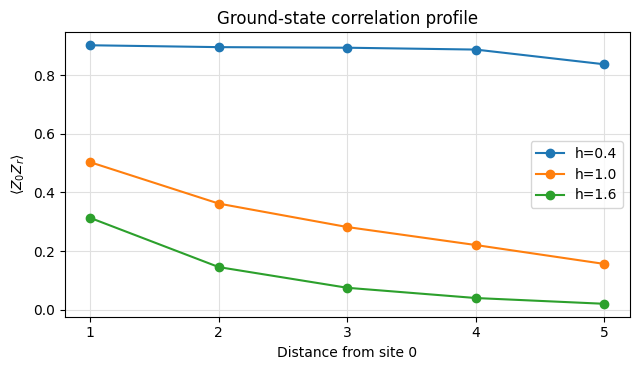

In [4]:
probe_fields = [0.4, 1.0, 1.6]
fig, ax = plt.subplots(figsize=(6.5, 3.8))
distances = np.arange(1, n_sites)
for field in probe_fields:
    H = longitudinal_field_ising(n_sites=n_sites, j=1.0, h_x=field, h_z=1e-3)
    _, state = ground_state(H)
    profile = [correlation_zz(state, n_sites, 0, distance) for distance in distances]
    ax.plot(distances, profile, marker="o", label=f"h={field:.1f}")
ax.set_xlabel("Distance from site 0")
ax.set_ylabel(r"$\langle Z_0Z_r\rangle$")
ax.set_title("Ground-state correlation profile")
ax.set_xticks(distances)
ax.grid(color="0.88", linewidth=0.8)
ax.legend()
fig.tight_layout()